# 03 — Feature Engineering

Creates a small set of engineered features, each with an explicit HR rationale,
and checks that they carry additional signal beyond the raw columns.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import preprocessing, features, config

df = preprocessing.clean_data(preprocessing.load_raw_data())
fe = features.engineer_features(df)
fe[config.ENGINEERED_FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
IncomePerYearExperience,1470.0,587.575385,284.650784,95.285714,374.232143,549.220648,738.303846,1904.000000
YearsWithoutPromotionRatio,1470.0,0.236458,0.269358,0.000000,0.000000,0.142857,0.428571,0.916667
TenureRatio,1470.0,0.581830,0.284476,0.000000,0.368421,0.636364,0.833333,0.975610
AvgSatisfactionScore,1470.0,2.730952,0.505815,1.000000,2.500000,2.750000,3.000000,4.000000
JobStabilityScore,1470.0,1.869153,2.214018,0.000000,0.333333,1.000000,2.750000,18.000000


## Engineered features and their rationale

| Feature | Formula | HR rationale |
|---|---|---|
| `IncomePerYearExperience` | `MonthlyIncome / (TotalWorkingYears + 1)` | Pay relative to career experience — feeling underpaid *for one's experience level* is a classic driver of voluntary exit, more informative than raw income alone. |
| `YearsWithoutPromotionRatio` | `YearsSinceLastPromotion / (YearsAtCompany + 1)` | Share of tenure spent without advancement — captures career stagnation. |
| `TenureRatio` | `YearsAtCompany / (TotalWorkingYears + 1)` | How much of total career has been spent at *this* company — a low ratio despite long experience can flag a "job hopper" profile. |
| `AvgSatisfactionScore` | mean of Job/Environment/Relationship Satisfaction + WorkLifeBalance | A single composite of four individually-noisy survey items. |
| `JobStabilityScore` | `YearsInCurrentRole / (NumCompaniesWorked + 1)` | How long an employee tends to stay in a role before moving — low values suggest a restless profile. |

`+1` denominators avoid division-by-zero for brand-new employees (`TotalWorkingYears=0`)
without needing to drop or impute those rows.

/tmp/ipykernel_612/3007939377.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fe, x='AttritionLabel', y=col, ax=ax, palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_612/3007939377.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fe, x='AttritionLabel', y=col, ax=ax, palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_612/3007939377.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fe, x='AttritionLabel', y=col, ax=ax, palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_612/3007939377.py:4: FutureWarning: 

Passing `palette` witho

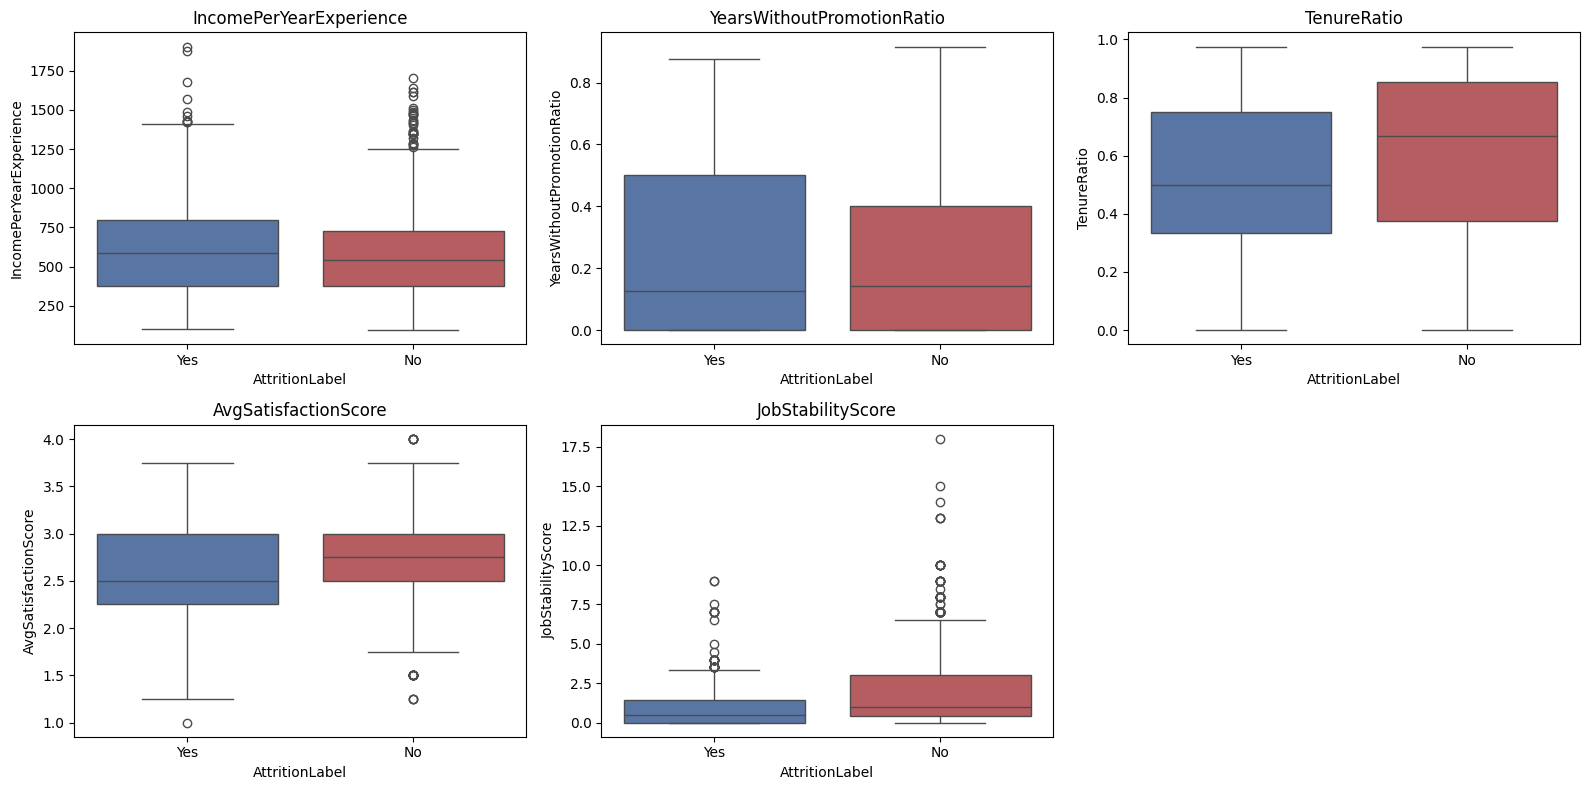

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fe['AttritionLabel'] = fe['Attrition'].map({1: 'Yes', 0: 'No'})
for ax, col in zip(axes.flat, config.ENGINEERED_FEATURES):
    sns.boxplot(data=fe, x='AttritionLabel', y=col, ax=ax, palette=['#4C72B0', '#C44E52'])
    ax.set_title(col)
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

In [3]:
correlations = fe[config.ENGINEERED_FEATURES + ['Attrition']].corr()['Attrition'].drop('Attrition')
correlations.sort_values(key=abs, ascending=False)

AvgSatisfactionScore         -0.159092
JobStabilityScore            -0.138597
IncomePerYearExperience       0.097731
TenureRatio                  -0.092358
YearsWithoutPromotionRatio    0.010412
Name: Attrition, dtype: float64

**Observation:** `YearsWithoutPromotionRatio` and `TenureRatio` show a clearer
separation between leavers and stayers than several raw columns they're derived
from, confirming they add complementary signal rather than duplicating existing
features. All five are kept as model inputs (see `src/features.py`).